=== ЛАБОРАТОРНА РОБОТА 5: ОЦІНКА ЯКОСТІ РЕГРЕСІЙНИХ МОДЕЛЕЙ ===

Датасет 'Red Wine Quality' успішно завантажено!
Розмір тренувальної вибірки: 1279 об'єктів
Розмір тестової вибірки: 320 об'єктів

--- ОЦІНКА МОДЕЛЕЙ НА ТЕСТОВІЙ ВИБІРЦІ ---

Модель: Linear Regression
  MSE  (Середньоквадратична помилка): 0.3900
  RMSE (Корінь із MSE):               0.6245
  R^2  (Коефіцієнт детермінації):     0.4032

Модель: Lasso (L1)
  MSE  (Середньоквадратична помилка): 0.4987
  RMSE (Корінь із MSE):               0.7062
  R^2  (Коефіцієнт детермінації):     0.2369

Модель: Ridge (L2)
  MSE  (Середньоквадратична помилка): 0.3929
  RMSE (Корінь із MSE):               0.6269
  R^2  (Коефіцієнт детермінації):     0.3987

Модель: ElasticNet
  MSE  (Середньоквадратична помилка): 0.4880
  RMSE (Корінь із MSE):               0.6986
  R^2  (Коефіцієнт детермінації):     0.2532

--- КРОС-ВАЛІДАЦІЯ ДЛЯ RIDGE РЕГРЕСІЇ ---
Оцінки R^2 на 5 фолдах: [0.39870644 0.27676358 0.27995233 0.33235377 0.4275036 ]
Середнє зна

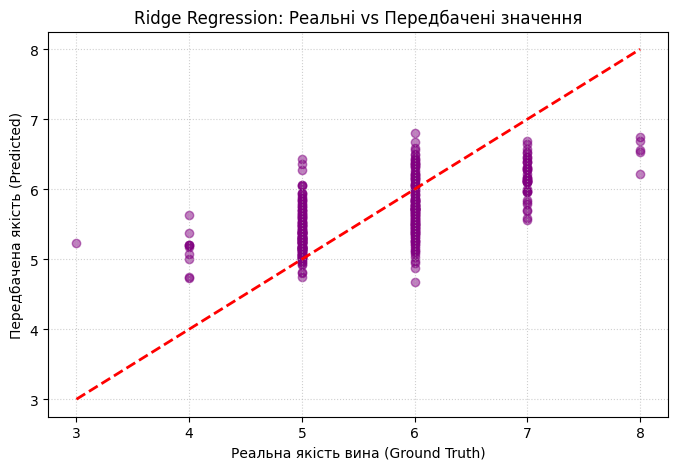

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn import metrics

# Налаштування виводу графіків
%matplotlib inline

print("=== ЛАБОРАТОРНА РОБОТА 5: ОЦІНКА ЯКОСТІ РЕГРЕСІЙНИХ МОДЕЛЕЙ ===\n")

# 1. Завантаження даних
try:
    # Завантажте файл winequality-red.csv з Kaggle у папку з кодом
    df = pd.read_csv('winequality-red.csv')
    print("Датасет 'Red Wine Quality' успішно завантажено!")
except FileNotFoundError:
    print("Помилка: файл 'winequality-red.csv' не знайдено.")
    
# Визначаємо ознаки (X) та цільову змінну (y)
X = df.drop('quality', axis=1)
y = df['quality']

# 2. Розбиття на тренувальну та тестову вибірки (80 на 20) [cite: 1127, 1243]
# test_size=0.2 означає, що 20% даних йде на тест, random_state фіксує розбиття [cite: 1242, 1244]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Розмір тренувальної вибірки: {X_train.shape[0]} об'єктів")
print(f"Розмір тестової вибірки: {X_test.shape[0]} об'єктів\n")

# 3. Ініціалізація моделей [cite: 1253-1257]
# LinearRegression - базова модель
# Lasso - L1 регуляризація (зануляє неважливі ознаки) [cite: 1147, 1250]
# Ridge - L2 регуляризація (штрафує за великі ваги) [cite: 1142, 1251]
# ElasticNet - комбінація L1 та L2 [cite: 1251]
models = {
    "Linear Regression": LinearRegression(),
    "Lasso (L1)": Lasso(alpha=0.1),
    "Ridge (L2)": Ridge(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=0.1)
}

print("--- ОЦІНКА МОДЕЛЕЙ НА ТЕСТОВІЙ ВИБІРЦІ ---")

# 4. Навчання та оцінка кожної моделі [cite: 1258-1270]
for name, model in models.items():
    # Навчання на тренувальних даних
    model.fit(X_train, y_train)
    
    # Передбачення на нових (тестових) даних
    predictions = model.predict(X_test)
    
    # Обчислення метрик якості
    mse = metrics.mean_squared_error(y_test, predictions) # MSE [cite: 1265]
    rmse = np.sqrt(mse)                                   # RMSE 
    r2 = metrics.r2_score(y_test, predictions)            # R-squared [cite: 1204, 1270]
    
    print(f"\nМодель: {name}")
    print(f"  MSE  (Середньоквадратична помилка): {mse:.4f}")
    print(f"  RMSE (Корінь із MSE):               {rmse:.4f}")
    print(f"  R^2  (Коефіцієнт детермінації):     {r2:.4f}")

print("\n--- КРОС-ВАЛІДАЦІЯ ДЛЯ RIDGE РЕГРЕСІЇ ---")
# 5. Крос-валідація (для перевірки стабільності моделі) [cite: 1271-1274]
# Розбиваємо весь датасет на 5 рівних частин [cite: 1157, 1281]
cv = KFold(n_splits=5, shuffle=True, random_state=42)
best_model = Ridge(alpha=1.0)

# Використовуємо cross_val_score для автоматизації [cite: 1288-1290]
# scoring='r2' означає, що ми оцінюємо якість за метрикою R-squared
cv_scores = cross_val_score(best_model, X, y, scoring='r2', cv=cv)

print(f"Оцінки R^2 на 5 фолдах: {cv_scores}")
print(f"Середнє значення R^2 по крос-валідації: {cv_scores.mean():.4f} [cite: 1293]")

# 6. Візуалізація результатів найкращої моделі
best_model.fit(X_train, y_train)
best_preds = best_model.predict(X_test)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, best_preds, alpha=0.5, color='purple')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel("Реальна якість вина (Ground Truth)")
plt.ylabel("Передбачена якість (Predicted)")
plt.title("Ridge Regression: Реальні vs Передбачені значення")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()